In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kddcup.data_10_percent_corrected to kddcup.data_10_percent_corrected


In [ ]:
import pandas as pd
import numpy as np

# Column names for the KDD dataset
column_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
    "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]

df = pd.read_csv('kddcup.data_10_percent_corrected', names=column_names, nrows=50000)

In [ ]:
print(df.shape)

(50000, 42)


In [ ]:
print(df.head())

   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   
3           

In [ ]:
print(df['label'].value_counts())

label
normal.             37966
smurf.              10503
back.                1000
ipsweep.              197
nmap.                 104
teardrop.              99
guess_passwd.          53
portsweep.             40
pod.                   20
ftp_write.              6
buffer_overflow.        3
satan.                  2
neptune.                2
loadmodule.             1
perl.                   1
land.                   1
imap.                   1
phf.                    1
Name: count, dtype: int64


In [ ]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)
print(df['label'].value_counts())

label
0    37966
1    12034
Name: count, dtype: int64


In [ ]:
df_numerical = df.select_dtypes(include=[np.number])
X = df_numerical.drop("label", axis=1)
y = df_numerical["label"]

print(f"Features shape: {X.shape}")
print(f"Attacks: {y.sum()}, Normal: {(y==0).sum()}")

Features shape: (50000, 38)
Attacks: 12034, Normal: 37966


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.1, random_state=42)
y_pred_iso = iso_model.fit_predict(X_scaled)

# IsolationForest returns -1 for anomalies, 1 for normal
# Converting to 0/1 to match our labels
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# Training on normal data
X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

input_dim = X_train.shape[1]

# autoencoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation="relu", activity_regularizer=regularizers.l1(1e-5))(input_layer)
encoded = Dense(8, activation="relu")(encoded)    # bottleneck
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer="adam", loss="mse")


autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, X_val),
    verbose=1
)

Epoch 1/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6230 - val_loss: 0.2518
Epoch 2/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4564 - val_loss: 0.1777
Epoch 3/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3828 - val_loss: 0.1559
Epoch 4/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3360 - val_loss: 0.1419
Epoch 5/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3000 - val_loss: 0.1301
Epoch 6/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2751 - val_loss: 0.1125
Epoch 7/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2491 - val_loss: 0.1052
Epoch 8/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2346 - val_loss: 0.1092
Epoch 9/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2206 - val_loss: 0.0972
Epoch 10/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2097 - val_loss: 0.0960


In [ ]:
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

# threshold at 95th percentile of normal data's error
threshold = np.percentile(mse[y == 0], 95)
y_pred_ae = [1 if err > threshold else 0 for err in mse]

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step



=== Isolation Forest ===
              precision    recall  f1-score   support

           0       0.78      0.93      0.85     37966
           1       0.44      0.18      0.26     12034

    accuracy                           0.75     50000
   macro avg       0.61      0.55      0.55     50000
weighted avg       0.70      0.75      0.71     50000



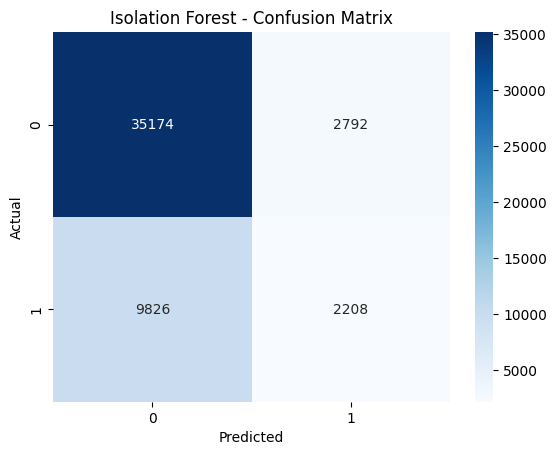


=== Autoencoder ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     37966
           1       0.86      0.98      0.92     12034

    accuracy                           0.96     50000
   macro avg       0.93      0.97      0.95     50000
weighted avg       0.96      0.96      0.96     50000



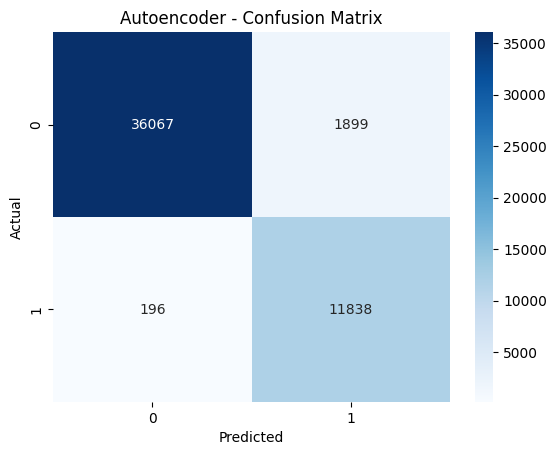

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model("Isolation Forest", y, y_pred_iso)
evaluate_model("Autoencoder", y, y_pred_ae)

In [ ]:
results = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Accuracy": accuracy_score(y, y_pred_iso),
        "Precision": precision_score(y, y_pred_iso),
        "Recall": recall_score(y, y_pred_iso),
        "F1 Score": f1_score(y, y_pred_iso)
    },
    {
        "Model": "Autoencoder",
        "Accuracy": accuracy_score(y, y_pred_ae),
        "Precision": precision_score(y, y_pred_ae),
        "Recall": recall_score(y, y_pred_ae),
        "F1 Score": f1_score(y, y_pred_ae)
    }
]).set_index("Model")

print(results)

                  Accuracy  Precision    Recall  F1 Score
Model                                                    
Isolation Forest   0.74764    0.44160  0.183480  0.259246
Autoencoder        0.95810    0.86176  0.983713  0.918707


In [ ]:
import joblib

joblib.dump(iso_model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
autoencoder.save('autoencoder_model.keras')